# Hydraulic Regime Detection

**Abriliam Consulting** — Industrial Energy Management

This notebook investigates the condenser water loop hydraulics to determine whether the plant operated in distinct hydraulic regimes during the monitoring period. A "regime change" — such as a valve position change, pump staging difference, or bypass condition — would alter the relationship between pressure drop (delta-P) and flow, and could explain the efficiency degradation observed in earlier notebooks.

We use a combination of scatter analysis, hydraulic coefficient calculation, and **Gaussian Mixture Model (GMM) clustering** to identify and classify operational regimes.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)

In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)

In [24]:
df.columns

Index(['oat_C', 'wb_C', 'occ', 'tons', 'chw_sup_C', 'chw_ret_C', 'chw_dT_C',
       'chw_flow_m3h', 'cw_sup_C', 'cw_ret_C', 'cw_dT_C', 'cw_flow_m3h',
       'approach_C', 'dp_kpa', 'chiller_kw', 'tower_fan_kw', 'chw_pump_kw',
       'cw_pump_kw', 'plant_kw', 'kw_per_ton', 'plant_kw_per_ton',
       'tower_fan_kw_per_ton', 'pumping_kw_per_ton', 'kw_per_ton_15_sma',
       'kw_per_ton_5_sma', 'kw_per_ton_24_sma', 'kw_per_ton_240_sma'],
      dtype='object')

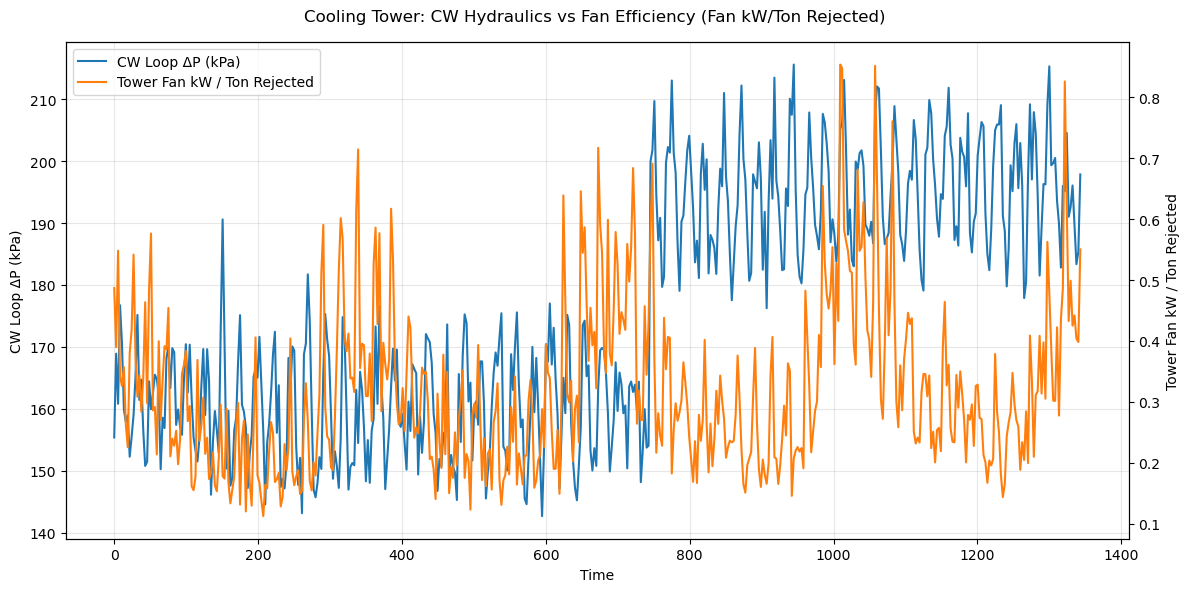

In [32]:
import matplotlib
matplotlib.use('Agg')
import numpy as np
import matplotlib.pyplot as plt

# --- Use df columns directly ---
t = df.index
dp_kpa = df["dp_kpa"]
tower_fan_kw = df["tower_fan_kw"]
cw_flow_m3h = df["cw_flow_m3h"]
cw_dT_C = df["cw_dT_C"]

# --- Heat rejection on CW side (kW) ---
rho_water = 1000.0      # kg/m3
cp_water = 4186.0       # J/kg-K
W_PER_TON = 3516.852842 # W per refrigeration ton

cw_flow_m3s = cw_flow_m3h / 3600.0
heat_rejection_kw = (rho_water * cp_water * cw_flow_m3s * cw_dT_C) / 1000.0  # kW

# Convert to tons rejected
tons_rejected_cw = (heat_rejection_kw * 1000.0) / W_PER_TON

# Avoid divide-by-zero / garbage when tons rejected is tiny
tons_rejected_cw = tons_rejected_cw.where(tons_rejected_cw > 1.0)  # threshold ton; adjust as needed

# --- Tower performance metric (fan-only boundary) ---
tower_fan_kw_per_ton_rejected = tower_fan_kw / tons_rejected_cw

# --- Create splined versions to match time_spline ---
time_numeric = np.arange(len(df.index))  # Convert time index to numeric for spline
_, dp_kpa_spline = create_spline(time_numeric, dp_kpa)
_, tower_fan_kw_per_ton_rejected_spline = create_spline(time_numeric, tower_fan_kw_per_ton_rejected.dropna())

# --- Plot with splined data ---
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(time_spline, dp_kpa_spline, label="CW Loop ΔP (kPa)", color="tab:blue" )  # ← change here)
ax1.set_xlabel("Time")
ax1.set_ylabel("CW Loop ΔP (kPa)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(time_spline, tower_fan_kw_per_ton_rejected_spline, label="Tower Fan kW / Ton Rejected", color="tab:orange")
ax2.set_ylabel("Tower Fan kW / Ton Rejected")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle("Cooling Tower: CW Hydraulics vs Fan Efficiency (Fan kW/Ton Rejected)")
plt.tight_layout()
plt.close("all")

### CW Loop Pressure vs Tower Fan Efficiency

This dual-axis plot shows the condenser water loop pressure drop alongside tower fan power per ton of heat rejected. Two distinct operating bands are visible — the system appears to operate at different pressure setpoints during the monitoring period. The fan efficiency metric (kW per ton rejected) helps normalize for load variation.


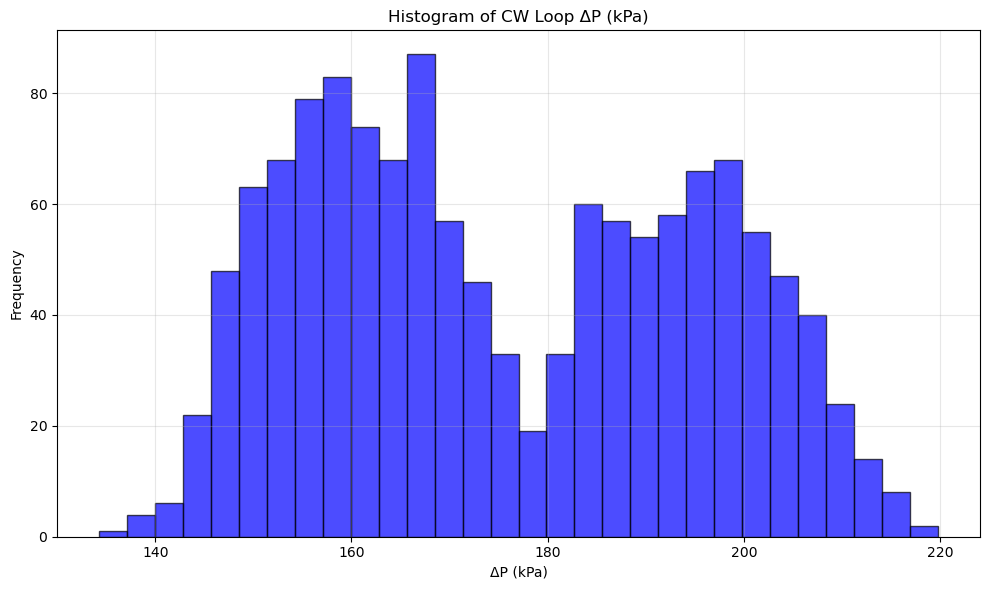

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(dp_kpa, bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Histogram of CW Loop ΔP (kPa)')
plt.xlabel('ΔP (kPa)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Pressure Drop Distribution

The histogram of CW loop delta-P reveals a **bimodal distribution** — two distinct clusters of operating pressure. This is strong evidence of a hydraulic regime change. A healthy, stable system would show a single peak that shifts with load. Two peaks suggest the system switched between configurations at some point during the monitoring period.


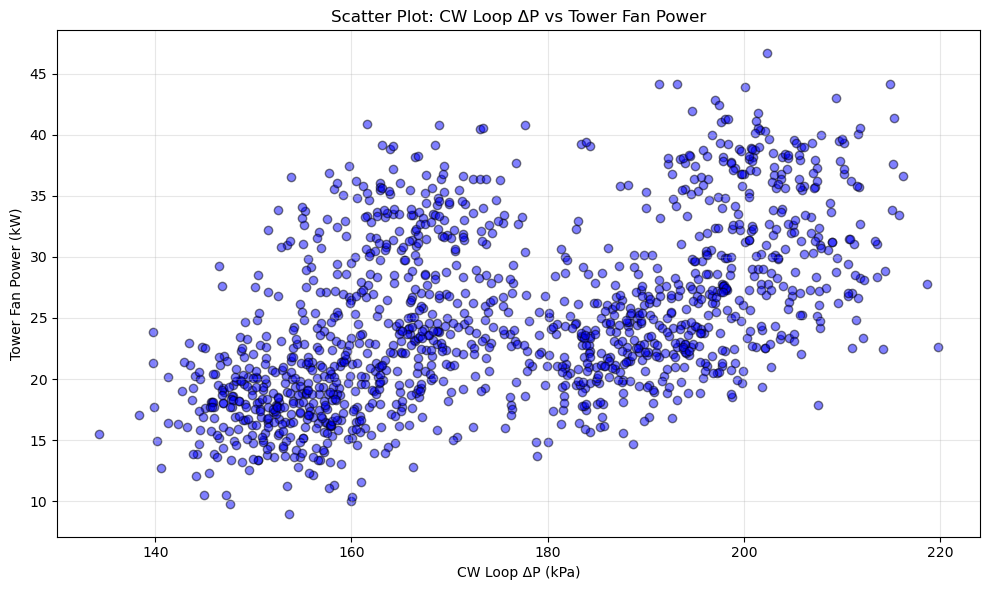

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(df['dp_kpa'], df['tower_fan_kw'], alpha=0.5, color='blue', edgecolor='k')
plt.title('Scatter Plot: CW Loop ΔP vs Tower Fan Power')
plt.xlabel('CW Loop ΔP (kPa)')
plt.ylabel('Tower Fan Power (kW)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Pressure Drop vs Fan Power

The scatter plot confirms two operating clusters. At higher differential pressures, the tower fans don't necessarily work harder — the excess pressure is being absorbed elsewhere in the system (possibly through a throttled valve or bypass). This is wasted pump energy.


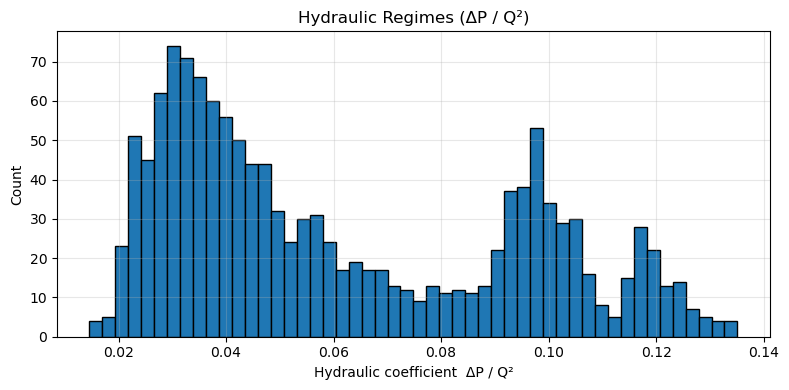

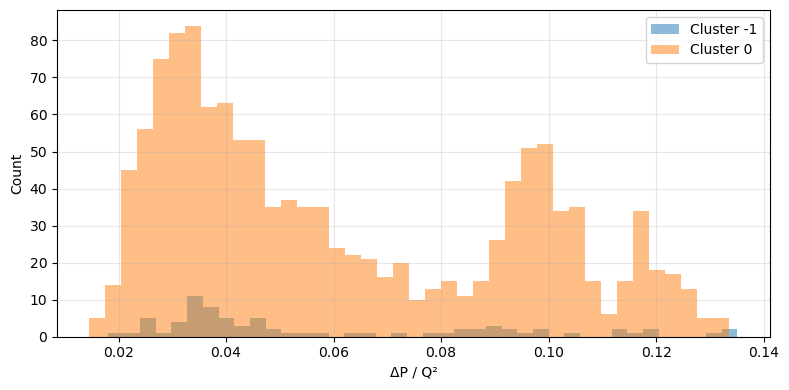

In [48]:
d2 = df[["dp_kpa", "cw_flow_m3h"]].dropna().copy()
d2 = d2[d2["cw_flow_m3h"] > 0]

d2["k_hyd"] = d2["dp_kpa"] / (d2["cw_flow_m3h"] ** 2)

plt.figure(figsize=(8,4))
plt.hist(d2["k_hyd"], bins=50, edgecolor="black")
plt.xlabel("Hydraulic coefficient  ΔP / Q²")
plt.ylabel("Count")
plt.title("Hydraulic Regimes (ΔP / Q²)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")


plt.figure(figsize=(8,4))
    plt.hist(
        d2.loc[mask, "k_hyd"],
        bins=40,
        alpha=0.5,
    )

plt.xlabel("ΔP / Q²")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")


### Hydraulic Coefficient Analysis

The hydraulic coefficient *k = delta-P / Q-squared* characterizes the system's flow resistance. In a fixed piping configuration, this coefficient should be roughly constant regardless of flow rate. A shift in *k* indicates a physical change — a valve opened or closed, a pump was staged differently, or a bypass condition changed.


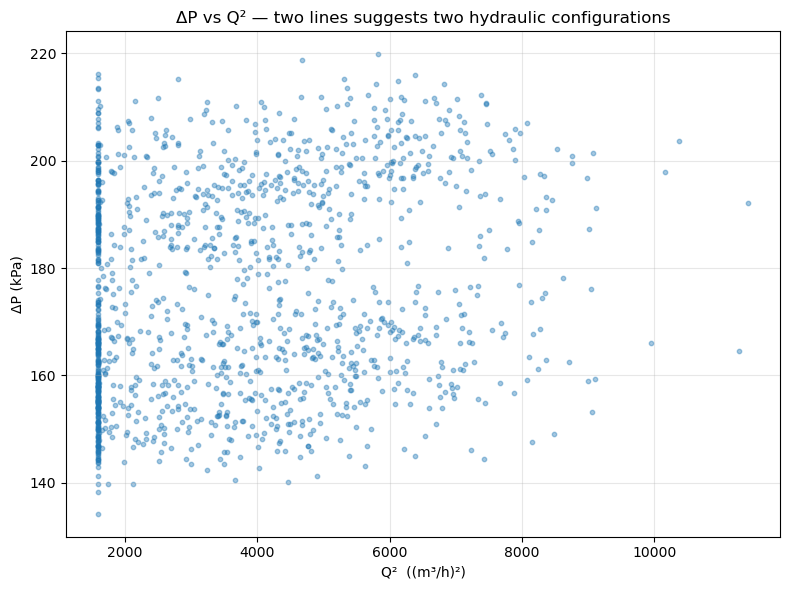

In [54]:
d4 = df[["dp_kpa", "cw_flow_m3h"]].dropna().copy()
d4 = d4[d4["cw_flow_m3h"] > 0]
d4["q2"] = d4["cw_flow_m3h"]**2

plt.figure(figsize=(8,6))
plt.scatter(d4["q2"], d4["dp_kpa"], s=10, alpha=0.4)
plt.xlabel("Q²  ((m³/h)²)")
plt.ylabel("ΔP (kPa)")
plt.title("ΔP vs Q² — two lines suggests two hydraulic configurations")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")


### Delta-P vs Q-Squared

Plotting pressure drop against flow-squared should yield a single line for a fixed hydraulic configuration (since delta-P is proportional to Q-squared by the Darcy-Weisbach equation). The presence of **two distinct linear relationships** confirms that the condenser water system operated in two different hydraulic configurations during the monitoring period.


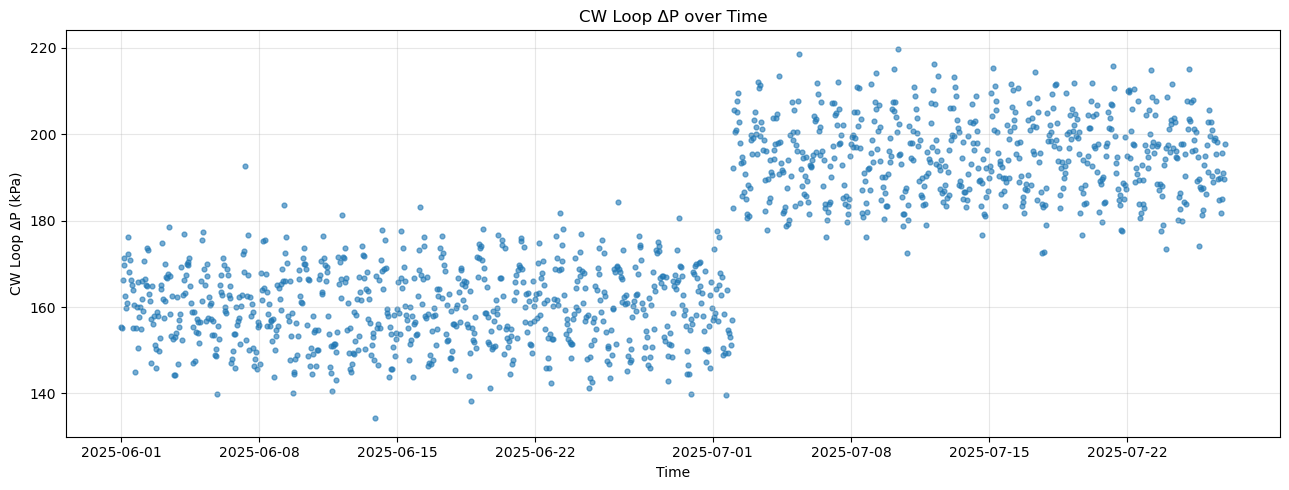

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))

plt.scatter(
    df.index,
    df["dp_kpa"],
    s=12,
    alpha=0.6
)

plt.xlabel("Time")
plt.ylabel("CW Loop ΔP (kPa)")
plt.title("CW Loop ΔP over Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")


### Pressure Drop Over Time

The time-series view of delta-P clearly shows when the regime change occurred — there's a visible step-change in the operating pressure around early July. This aligns with the efficiency degradation detected by the CUSUM analysis in Notebook 03.


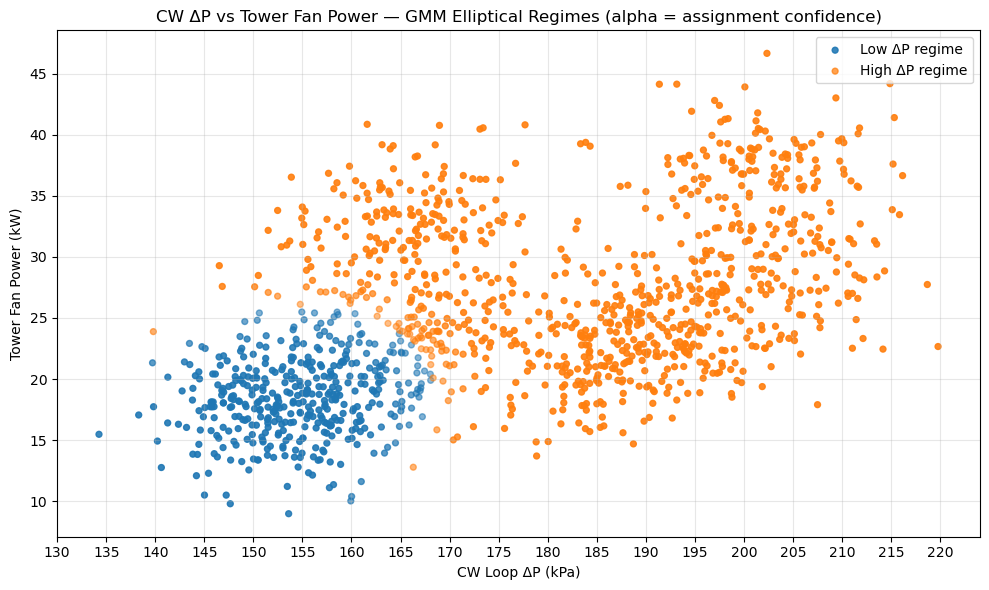

Counts by regime:
regime
0    422
1    922
Name: count, dtype: int64

Median confidence by regime:
regime
0    0.931134
1    0.999971
Name: confidence, dtype: float64


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# --- Data: choose features that define the regime ---
d = df[["dp_kpa", "tower_fan_kw"]].dropna().copy()

X = d[["dp_kpa", "tower_fan_kw"]].values

# Scale so dp and kW have equal weight in clustering
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Fit a 2-component GMM (elliptical clusters)
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=0
)
labels = gmm.fit_predict(Xs)

# Soft assignment (probability of belonging to each cluster)
proba = gmm.predict_proba(Xs)
confidence = proba.max(axis=1)

d["regime"] = labels
d["confidence"] = confidence

# --- Plot (no ellipses) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Optional: make regime labels consistently "Low ΔP" vs "High ΔP"
# (GMM component numbers are arbitrary)
dp_mean_by_regime = d.groupby("regime")["dp_kpa"].mean()
low_reg = dp_mean_by_regime.idxmin()
high_reg = dp_mean_by_regime.idxmax()
label_map = {low_reg: "Low ΔP regime", high_reg: "High ΔP regime"}

# Color by regime; fade low-confidence "bridge" points
for k in sorted(d["regime"].unique()):
    dk = d[d["regime"] == k]
    ax.scatter(
        dk["dp_kpa"], dk["tower_fan_kw"],
        s=18,
        alpha=np.clip(dk["confidence"].values, 0.15, 0.9),
        label=label_map.get(k, f"Regime {k}")
    )

ax.set_xlabel("CW Loop ΔP (kPa)")
ax.set_ylabel("Tower Fan Power (kW)")
ax.set_title("CW ΔP vs Tower Fan Power — GMM Elliptical Regimes (alpha = assignment confidence)")
ax.grid(alpha=0.3)

# X-axis ticks every 5 kPa
x_min = np.floor(d["dp_kpa"].min() / 5) * 5
x_max = np.ceil(d["dp_kpa"].max() / 5) * 5
ax.set_xticks(np.arange(x_min, x_max + 5, 5))

ax.legend()
plt.tight_layout()
plt.close("all")

# Optional: quick counts / confidence summary
print("Counts by regime:")
print(d["regime"].value_counts().sort_index())
print("\nMedian confidence by regime:")
print(d.groupby("regime")["confidence"].median().sort_index())


### GMM Clustering Results

A **Gaussian Mixture Model** with two components cleanly separates the two hydraulic regimes. The point opacity represents classification confidence — darker points are confidently assigned to one regime, while lighter "bridge" points represent transitional hours.

The two regimes correspond to:
- **Low delta-P regime**: The system operating at normal differential pressure (pre-change)
- **High delta-P regime**: Elevated differential pressure, likely due to a control setpoint change or valve position shift

This unsupervised classification can be used to automatically segment operating data for regime-specific analysis and alerting.
